In [1]:
!nvidia-smi

Fri Feb 20 04:24:27 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

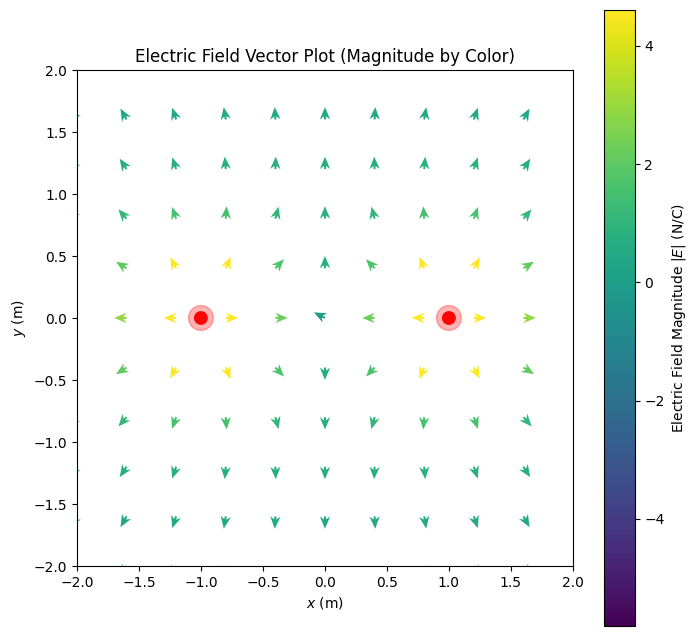

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

k = 1.0

def E(q, r0, x, y):
    den = np.hypot(x - r0[0], y - r0[1])**3

    Ex = k * q * (x - r0[0]) / den
    Ey = k * q * (y - r0[1]) / den

    # 電荷位置をNaNとして描画から除外
    Ex[den == 0] = np.nan
    Ey[den == 0] = np.nan

    return Ex, Ey

# --- 設定パラメータ ---

X_MIN, X_MAX = -2, 2
Y_MIN, Y_MAX = -2, 2
NX, NY = 3000, 3000  # グリッドの分割数

R_CUTOFF = 0.1 # 電荷の中心からこの距離内にあるグリッド点を計算から除外

charges = [
    (1, (-1.0, 0.0)),  # 正電荷 +1
    (1, (1.0, 0.0))   # 負電荷 -1
]

# --- メイン処理 ---

x = np.linspace(X_MIN, X_MAX, NX)
y = np.linspace(Y_MIN, Y_MAX, NY)
X, Y = np.meshgrid(x, y)

Ex, Ey = np.zeros((NY, NX)), np.zeros((NY, NX))

# 電場の重ね合わせ
for q, pos in charges:
    ex_i, ey_i = E(q, pos, x=X, y=Y)

    # 距離の計算
    Rx = X - pos[0]
    Ry = Y - pos[1]
    R = np.hypot(Rx, Ry)

    # R_CUTOFFより小さい距離の点の電場をNaNに設定
    mask = R < R_CUTOFF
    ex_i[mask] = np.nan
    ey_i[mask] = np.nan

    Ex += ex_i
    Ey += ey_i

# ★★★ ここから Quiver Plot のための変更 ★★★

# 1. 電場ベクトルの大きさ (絶対値) を計算
E_magnitude = np.hypot(Ex, Ey)

# 2. 電場ベクトルの正規化（単位ベクトル化）
# NaNやゼロで割るのを避けるため、マスク処理
non_zero_E = E_magnitude != 0
Ux = np.full_like(Ex, np.nan) # 初期値をNaNで埋める
Uy = np.full_like(Ey, np.nan) # 初期値をNaNで埋める

Ux[non_zero_E] = Ex[non_zero_E] / E_magnitude[non_zero_E]
Uy[non_zero_E] = Ey[non_zero_E] / E_magnitude[non_zero_E]


# --- 描画 ---
fig, ax = plt.subplots(figsize=(8, 8))

# 矢印の間引き設定
m, n = 300, 300

# 矢印の色を電場強度にマッピングするため、`cmap`を使用
# カラーバーも表示できるように `scatter` の要領で `quiver` の色を設定
# `quiver` の `color` 引数には、カラーマップに正規化された値を渡す

# カラーマップの準備
cmap = plt.cm.viridis # または他のカラーマップ (e.g., inferno, plasma, hot)
#norm = plt.Normalize(vmin=np.nanmin(E_magnitude), vmax=np.nanmax(E_magnitude))
norm = plt.Normalize(vmin=np.nanmin(np.log(E_magnitude[E_magnitude > 0])), vmax=np.nanmax(np.log(E_magnitude[E_magnitude > 0])))
#color_data = np.log(E_magnitude[::n, ::m]) # 対数スケールを使う場合

color_data = E_magnitude[::n, ::m]


qv = ax.quiver(X[::n, ::m], Y[::n, ::m],
               Ux[::n, ::m], Uy[::n, ::m],
               color_data, # 色データとして電場強度を渡す
               cmap=cmap,  # カラーマップを指定
               norm=norm,  # 色の正規化 (vmin, vmax)
               scale=40,   # 矢印の長さを固定する (単位ベクトルにしているので)
               width=0.005,
               headwidth=5, # 矢印の頭の幅
               headlength=6 # 矢印の頭の長さ
              )

# カラーバーの追加
cbar = fig.colorbar(qv, ax=ax, orientation='vertical', pad=0.05)
cbar.set_label('Electric Field Magnitude $|E|$ (N/C)')


# 電荷の位置を円で描画
charge_colors = {True: 'red', False: 'blue'}
for q, pos in charges:
    ax.add_artist(Circle(pos, R_CUTOFF, color=charge_colors[q > 0], alpha=0.3)) # 除去領域も表示
    ax.add_artist(Circle(pos, 0.05, color=charge_colors[q > 0])) # 電荷の中心

# 軸ラベルと範囲の設定
ax.set_xlabel('$x$ (m)')
ax.set_ylabel('$y$ (m)')
ax.set_title('Electric Field Vector Plot (Magnitude by Color)')
ax.set_xlim(X_MIN, X_MAX)
ax.set_ylim(Y_MIN, Y_MAX)
ax.set_aspect('equal')
plt.show()

--- 積分結果 ---
囲まれた電荷 (Q_in): 2.000
ガウスの法則による期待されるフラックス (Q_in / ε₀): 25.133
辺 1 (FLUX): 7.912
辺 1 (CIRC): -0.000
辺 2 (FLUX): 12.955
辺 2 (CIRC): 0.000
辺 3 (FLUX): 7.912
辺 3 (CIRC): -0.000
辺 4 (FLUX): 12.955
辺 4 (CIRC): 0.000
--- 閉経路の結果 ---
総フラックス (ΣΦ): 41.734 (ガウスの法則: Φ = Q_in / ε₀)
総循環 (ΣΓ): 0.000 (静電場では $\oint \vecE \cdot d\vecl = 0$)
--------------------


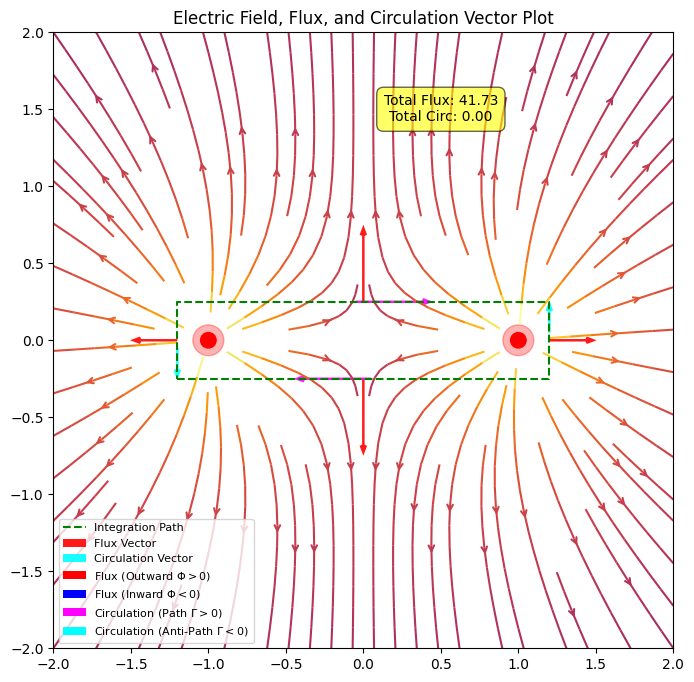

In [ ]:
# --- 5. フラックスと循環の計算のためのコード追加 ---

# 計算を行う四角形の頂点 (例: 中心(0, 0)、幅1.5、高さ1.0)
x_center, y_center = 0.0, 0.0
x_width, y_height = 2.4, 0.5

# 四角形の頂点座標 (反時計回り)
x1 = x_center - x_width / 2
x2 = x_center + x_width / 2
y1 = y_center - y_height / 2
y2 = y_center + y_height / 2

# 積分に使用する分割数
N_LINE = 50

# 経路の定義: (辺の始点, 辺の終点, 積分要素 dLの向き/法線ベクトル nの向き)
# 辺1: 左 (下から上) - ガウスの法則では外向き法線 (n=(-1, 0)), 循環では dL=(0, +1)
line1 = {'start': (x1, y1), 'end': (x1, y2), 'nx': -1, 'ny': 0, 'dlx': 0, 'dly': 1}
# 辺2: 上 (左から右) - 外向き法線 (n=(0, +1)), 循環では dL=(+1, 0)
line2 = {'start': (x1, y2), 'end': (x2, y2), 'nx': 0, 'ny': 1, 'dlx': 1, 'dly': 0}
# 辺3: 右 (上から下) - 外向き法線 (n=(+1, 0)), 循環では dL=(0, -1)
line3 = {'start': (x2, y2), 'end': (x2, y1), 'nx': 1, 'ny': 0, 'dlx': 0, 'dly': -1}
# 辺4: 下 (右から左) - 外向き法線 (n=(0, -1)), 循環では dL=(-1, 0)
line4 = {'start': (x2, y1), 'end': (x1, y1), 'nx': 0, 'ny': -1, 'dlx': -1, 'dly': 0}

lines = [line1, line2, line3, line4]

total_flux = 0.0
total_circulation = 0.0
fluxes = {}
circulations = {}

# クーロン定数 k = 1 / 4πε₀ を使って ε₀ = 1 / (4πk) を計算 (ここでは k=1.0)
# ガウスの法則: Φ = Q_in / ε₀ = Q_in * 4πk
Q_enclosed = sum(q for q, pos in charges if x1 < pos[0] < x2 and y1 < pos[1] < y2)
gauss_flux_expected = Q_enclosed * 4 * np.pi * k

print(f"--- 積分結果 ---")
print(f"囲まれた電荷 (Q_in): {Q_enclosed:.3f}")
print(f"ガウスの法則による期待されるフラックス (Q_in / ε₀): {gauss_flux_expected:.3f}")


for i, line in enumerate(lines):
    # 線積分用の座標点を作成
    xs = np.linspace(line['start'][0], line['end'][0], N_LINE)
    ys = np.linspace(line['start'][1], line['end'][1], N_LINE)

    # 積分要素の大きさ dL (N_LINE-1個の要素)
    dL = np.hypot(line['end'][0] - line['start'][0], line['end'][1] - line['start'][1]) / (N_LINE - 1)

    # 各点での電場 E を計算 (境界は含まず、中央の N_LINE-1 点を使用)
    Ex_line, Ey_line = np.zeros(N_LINE - 1), np.zeros(N_LINE - 1)

    for j in range(N_LINE - 1):
        # 積分点 (各セグメントの中点)
        mid_x = (xs[j] + xs[j+1]) / 2
        mid_y = (ys[j] + ys[j+1]) / 2

        # すべての電荷からの電場を重ね合わせる
        E_mid_x, E_mid_y = 0.0, 0.0
        for q, pos in charges:
            den = np.hypot(mid_x - pos[0], mid_y - pos[1])**3
            # 電荷位置での発散を避ける（R_CUTOFF内でも同様のチェックが必要だが、ここでは簡単化）
            if den != 0 and np.hypot(mid_x - pos[0], mid_y - pos[1]) > R_CUTOFF:
                E_mid_x += k * q * (mid_x - pos[0]) / den
                E_mid_y += k * q * (mid_y - pos[1]) / den

        Ex_line[j] = E_mid_x
        Ey_line[j] = E_mid_y


    # ------------------ フラックスの計算 (Φ = ∫ E・n dL) ------------------
    # E・n = Ex * nx + Ey * ny
    dot_prod_flux = Ex_line * line['nx'] + Ey_line * line['ny']
    flux = np.sum(dot_prod_flux) * dL
    total_flux += flux

    fluxes[i] = flux

    # ------------------ 循環の計算 (Γ = ∫ E・dL) ------------------
    # E・dL = Ex * dLx + Ey * dLy
    dot_prod_circ = Ex_line * line['dlx'] + Ey_line * line['dly']
    circulation = np.sum(dot_prod_circ) * dL
    total_circulation += circulation

    circulations[i] = circulation

    print(f"辺 {i+1} (FLUX): {flux:.3f}")
    print(f"辺 {i+1} (CIRC): {circulation:.3f}")

print(f"--- 閉経路の結果 ---")
print(f"総フラックス (ΣΦ): {total_flux:.3f} (ガウスの法則: Φ = Q_in / ε₀)")
print(f"総循環 (ΣΓ): {total_circulation:.3f} (静電場では $\\oint \\vec{"E"} \\cdot d\\vec{"l"} = 0$)")
print("--------------------")

# --- 6. 結果の図示 ---

fig, ax = plt.subplots(figsize=(8, 8))
# Quiver plot の後の描画に追加
color = np.log(np.hypot(Ex, Ey))
ax.streamplot(x, y, Ex, Ey,
              color=color,
              linewidth=1.5,
              cmap=plt.cm.inferno,
              density=1,  # 密度の調整
              arrowstyle='->',
              arrowsize=1)
ax.plot([x1, x2, x2, x1, x1], [y1, y1, y2, y2, y1], 'g--', label='Integration Path') # 四角形を描画
charge_colors = {True: 'red', False: 'blue'}
for q, pos in charges:
    ax.add_artist(Circle(pos, R_CUTOFF, color=charge_colors[q > 0], alpha=0.3)) # 除去領域も表示
    ax.add_artist(Circle(pos, 0.05, color=charge_colors[q > 0])) # 電荷の中心
# 各辺のフラックスと循環をテキストで表示
#text_props = {'fontsize': 8, 'ha': 'center', 'bbox': dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3')}

# 辺1: 左 (y軸中央)
#ax.text(x1 - 0.15, y_center, f'Φ: {fluxes[0]:.2f}\nΓ: {circulations[0]:.2f}', **text_props)
# 辺2: 上 (x軸中央)
#ax.text(x_center, y2 + 0.15, f'Φ: {fluxes[1]:.2f}\nΓ: {circulations[1]:.2f}', **text_props)
# 辺3: 右 (y軸中央)
#ax.text(x2 + 0.15, y_center, f'Φ: {fluxes[2]:.2f}\nΓ: {circulations[2]:.2f}', **text_props)
# 辺4: 下 (x軸中央)
#ax.text(x_center, y1 - 0.15, f'Φ: {fluxes[3]:.2f}\nΓ: {circulations[3]:.2f}', **text_props)

# 閉経路全体の結果も表示
#ax.text(x_center, y_center,
#        f'Total Flux: {total_flux:.2f}\nTotal Circ: {total_circulation:.2f}',
#        fontsize=10, ha='center', va='center', color='black',
#        bbox=dict(facecolor='yellow', alpha=0.6, edgecolor='black', boxstyle='round,pad=0.5'))
SCALE_FACTOR = 0.5
FLUX_SCALE = 1.0 / np.nanmax(np.abs(list(fluxes.values()))) * SCALE_FACTOR
CIRC_SCALE = 1.0 / np.nanmax(np.abs(list(circulations.values()))) * SCALE_FACTOR


# 各辺のフラックスと循環をベクトルで表示
for i, line in enumerate(lines):
    flux = fluxes[i]
    circ = circulations[i]

    # 辺の中点座標 (Quiverの始点)
    mid_x = (line['start'][0] + line['end'][0]) / 2
    mid_y = (line['start'][1] + line['end'][1]) / 2

    # --- A. フラックスのベクトル表示 (法線方向) ---

    # 1. ベクトルの方向と大きさ (法線方向 n = (nx, ny))
    # フラックスの絶対値が大きさ、符号が向き

    # 向きの符号: flux > 0 なら法線nと同じ向き、flux < 0 なら法線nと逆向き
    direction_sign_flux = np.sign(flux)

    # 矢印の色: 正のフラックス（外向き）は赤、負のフラックス（内向き）は青
    flux_color = 'red' if flux >= 0 else 'blue'

    # ベクトルのU, V成分
    U_flux = direction_sign_flux * line['nx'] * abs(flux) * FLUX_SCALE
    V_flux = direction_sign_flux * line['ny'] * abs(flux) * FLUX_SCALE

    # Quiverによる描画（フラックス）
    ax.quiver(mid_x, mid_y, U_flux, V_flux,
              color=flux_color,
              scale=1.0, # U,Vに絶対値とスケール係数を含めているので、scale=1.0とする
              scale_units='xy',
              width=0.004,
              headwidth=3,
              headlength=4,
              alpha=0.9,
              label='Flux Vector' if i == 0 else "")


    # --- B. 循環のベクトル表示 (接線方向) ---

    # 1. ベクトルの方向と大きさ (接線方向 dl = (dlx, dly))

    # 向きの符号: circ > 0 なら dlと同じ向き、circ < 0 なら dlと逆向き
    direction_sign_circ = np.sign(circ)

    # 矢印の色: 正の循環（経路順）はマゼンタ、負の循環（逆順）はシアン
    circ_color = 'magenta' if circ >= 0 else 'cyan'

    # ベクトルのU, V成分
    U_circ = direction_sign_circ * line['dlx'] * abs(circ) * CIRC_SCALE
    V_circ = direction_sign_circ * line['dly'] * abs(circ) * CIRC_SCALE

    # Quiverによる描画（循環）
    # わずかにオフセットさせてフラックスベクトルと重ならないようにする
    offset = 0.05
    offset_x = -line['ny'] * offset # 法線方向に直交
    offset_y = line['nx'] * offset

    ax.quiver(mid_x + offset_x, mid_y + offset_y, U_circ, V_circ,
              color=circ_color,
              scale=1.0,
              scale_units='xy',
              width=0.004,
              headwidth=3,
              headlength=4,
              alpha=0.9,
              label='Circulation Vector' if i == 0 else "")

# 凡例の再作成 (ラベルが重複しないように)
# 便宜的にダミーのプロットで凡例を作成
ax.quiver([], [], [], [], color='red', label='Flux (Outward $\\Phi > 0$)')
ax.quiver([], [], [], [], color='blue', label='Flux (Inward $\\Phi < 0$)')
ax.quiver([], [], [], [], color='magenta', label='Circulation (Path $\\Gamma > 0$)')
ax.quiver([], [], [], [], color='cyan', label='Circulation (Anti-Path $\\Gamma < 0$)')

ax.legend(loc='lower left', fontsize=8)

# 閉経路全体の結果も表示 (テキストは残しておくのが分かりやすい)
ax.text(0.5, 1.5,
        f'Total Flux: {total_flux:.2f}\nTotal Circ: {total_circulation:.2f}',
        fontsize=10, ha='center', va='center', color='black',
        bbox=dict(facecolor='yellow', alpha=0.6, edgecolor='black', boxstyle='round,pad=0.5'))

ax.set_title('Electric Field, Flux, and Circulation Vector Plot')

#ax.legend(loc='lower left')
plt.show()

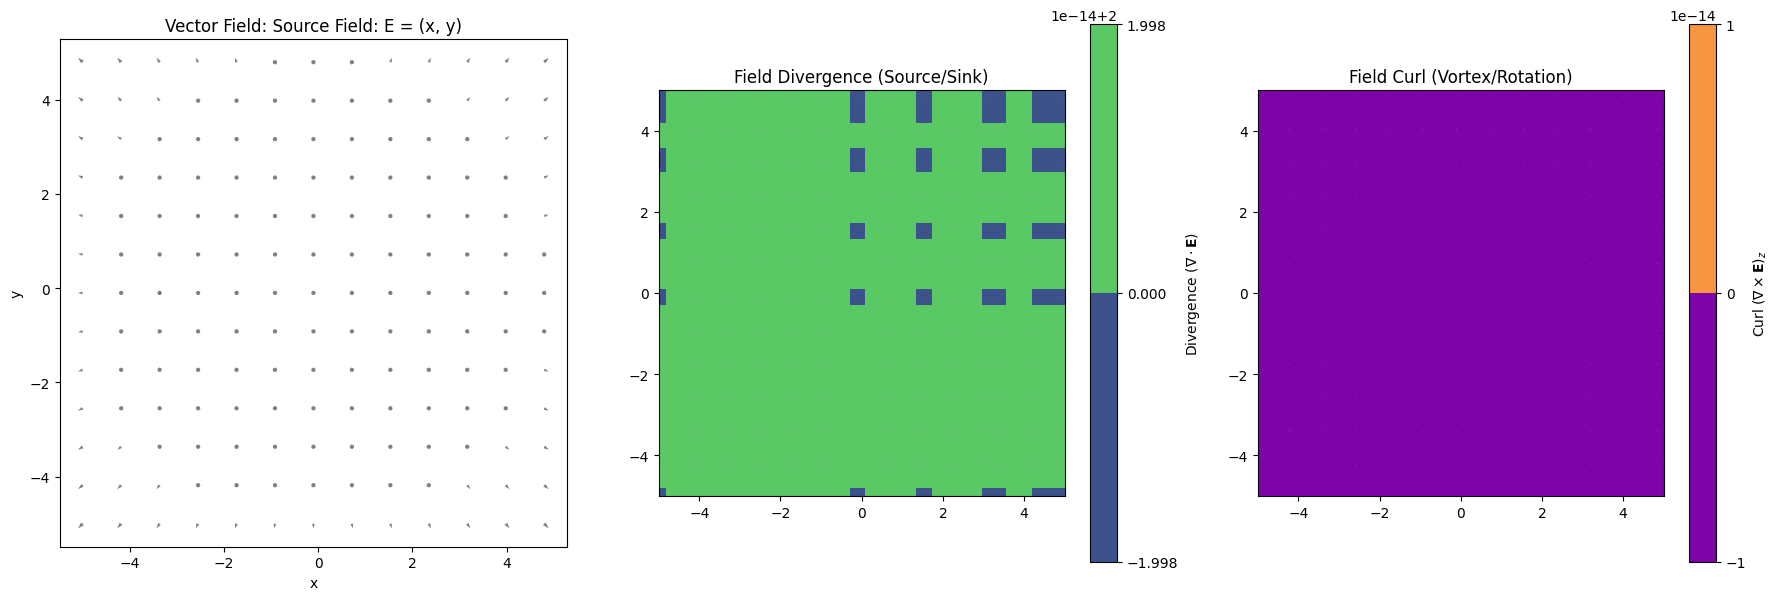

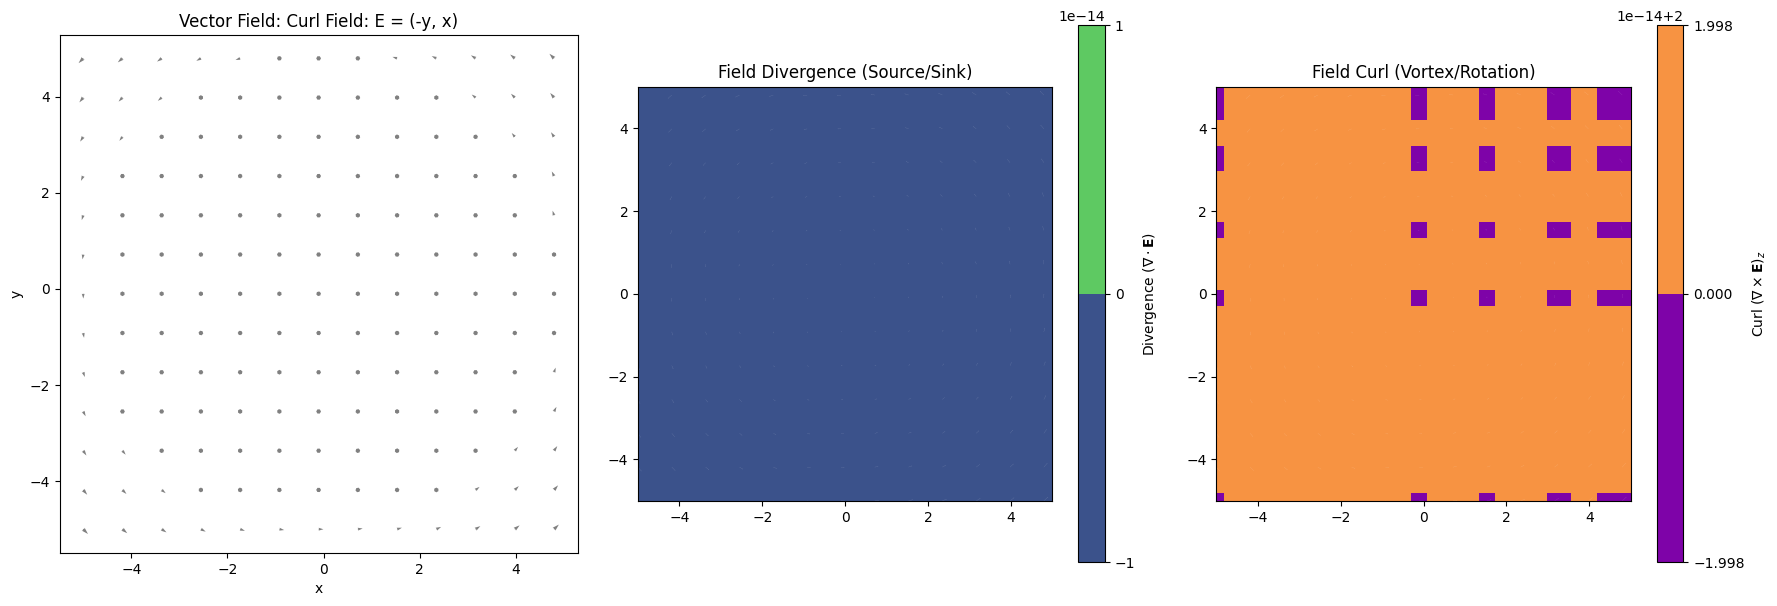

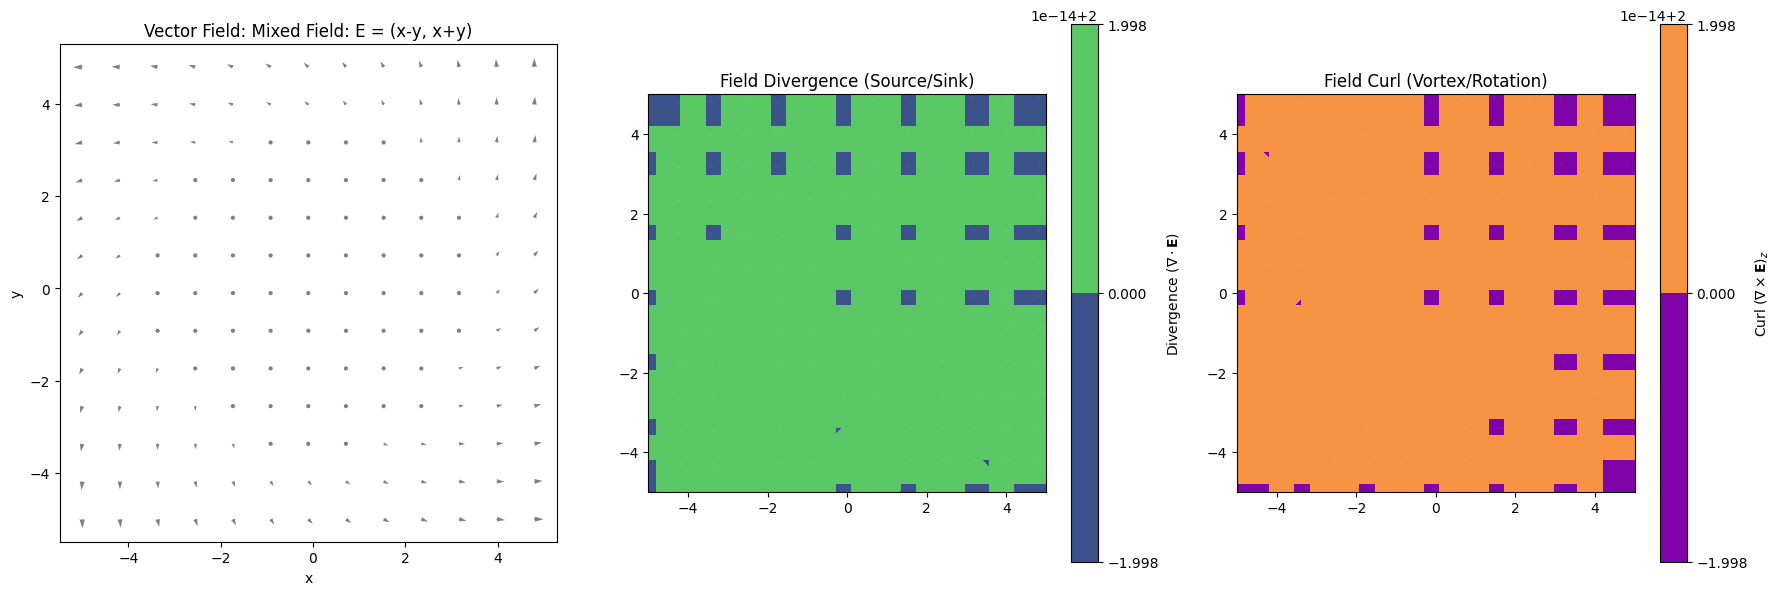

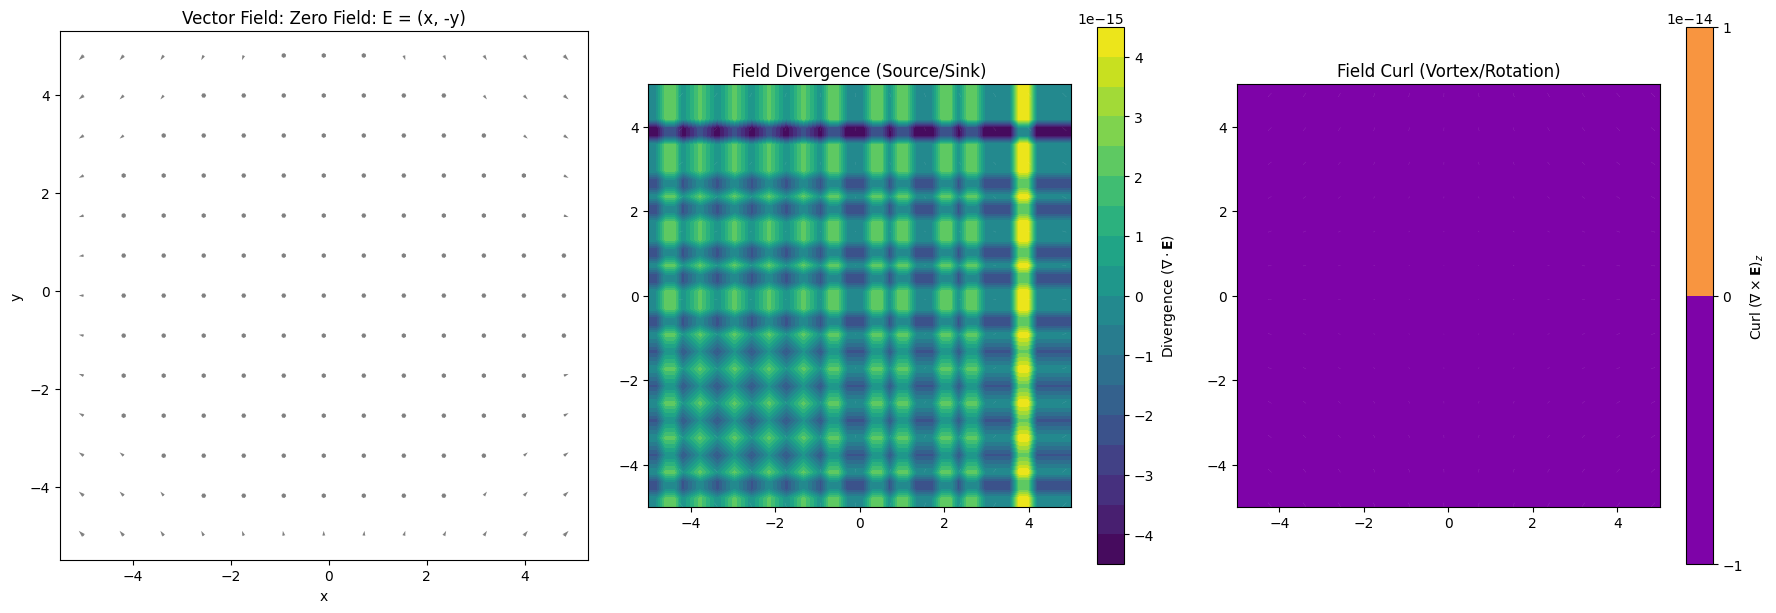

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. 定義 ---

def create_grid(x_range=(-5, 5), y_range=(-5, 5), n=50):
    """描画グリッド (X, Y) を作成し、グリッドの座標を返す。"""
    x = np.linspace(x_range[0], x_range[1], n)
    y = np.linspace(y_range[0], y_range[1], n)
    X, Y = np.meshgrid(x, y)
    return X, Y

def calculate_div(Ex, Ey, dx, dy):
    """ベクトル場 E の発散 (div) を数値的に計算する。"""
    # NumPyの勾配関数 np.gradient を使用
    dEx_dx = np.gradient(Ex, dx, axis=1) # Exのx方向微分
    dEy_dy = np.gradient(Ey, dy, axis=0) # Eyのy方向微分
    return dEx_dx + dEy_dy

def calculate_rot_z(Ex, Ey, dx, dy):
    """ベクトル場 E の回転 (rot) のz成分を数値的に計算する。(rot E)_z"""
    dEy_dx = np.gradient(Ey, dx, axis=1) # Eyのx方向微分
    dEx_dy = np.gradient(Ex, dy, axis=0) # Exのy方向微分
    return dEy_dx - dEx_dy

# --- 2. ベクトル場の例 ---

def field_source(X, Y):
    """湧き出しのみ (Source Field): E = (x, y)"""
    return X, Y

def field_curl(X, Y):
    """回転のみ (Curl Field): E = (-y, x)"""
    return -Y, X

def field_mixed(X, Y):
    """湧き出しと回転 (Mixed Field): E = (x-y, x+y)"""
    return X - Y, X + Y

def field_zero(X, Y):
    """どちらもなし (Zero Field): E = (x, -y)"""
    return X, -Y

# --- 3. 可視化関数 ---

def plot_field_analysis(field_func, title):
    """ベクトル場、発散、回転をまとめてプロットする。"""
    X, Y = create_grid()
    Ex, Ey = field_func(X, Y)

    # グリッド間隔
    dx = X[0, 1] - X[0, 0]
    dy = Y[1, 0] - Y[0, 0]

    Div = calculate_div(Ex, Ey, dx, dy)
    RotZ = calculate_rot_z(Ex, Ey, dx, dy)

    # 矢印の間引き (描画負荷軽減)
    skip = 4

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # a) ベクトル場 (Quiver)
    ax = axes[0]
    ax.quiver(X[::skip, ::skip], Y[::skip, ::skip], Ex[::skip, ::skip], Ey[::skip, ::skip],
              scale=50, units='xy', width=0.1, color='gray')
    ax.set_title(f'Vector Field: {title}')
    ax.set_aspect('equal')
    ax.set_xlabel('x')
    ax.set_ylabel('y')

    # b) 発散 (Color Map)
    ax = axes[1]
    c = ax.contourf(X, Y, Div, levels=20, cmap='viridis')
    fig.colorbar(c, ax=ax, orientation='vertical').set_label('Divergence ($\\nabla \\cdot \\mathbf{E}$)')
    ax.quiver(X[::skip, ::skip], Y[::skip, ::skip], Ex[::skip, ::skip], Ey[::skip, ::skip],
              scale=50, units='xy', width=0.003, color='white', alpha=0.5)
    ax.set_title('Field Divergence (Source/Sink)')
    ax.set_aspect('equal')

    # c) 回転 (Color Map)
    ax = axes[2]
    c = ax.contourf(X, Y, RotZ, levels=20, cmap='plasma')
    fig.colorbar(c, ax=ax, orientation='vertical').set_label('Curl ($\\nabla \\times \\mathbf{E})_z$')
    ax.quiver(X[::skip, ::skip], Y[::skip, ::skip], Ex[::skip, ::skip], Ey[::skip, ::skip],
              scale=50, units='xy', width=0.003, color='white', alpha=0.5)
    ax.set_title('Field Curl (Vortex/Rotation)')
    ax.set_aspect('equal')

    plt.tight_layout()
    plt.show()

# --- 4. 実行 ---

# 1. 湧き出しがある場 (発散 ≠ 0, 回転 = 0)
plot_field_analysis(field_source, 'Source Field: E = (x, y)')

# 2. 循環がある場 (発散 = 0, 回転 ≠ 0)
plot_field_analysis(field_curl, 'Curl Field: E = (-y, x)')

# 3. どちらもある場 (発散 ≠ 0, 回転 ≠ 0)
plot_field_analysis(field_mixed, 'Mixed Field: E = (x-y, x+y)')

# 4. どちらもない場 (発散 = 0, 回転 = 0)
plot_field_analysis(field_zero, 'Zero Field: E = (x, -y)')